# Notebook 04 - TF-IDF Baseline Models

This notebook implements classical machine learning approaches using TF-IDF feature representations. Text data is vectorised using unigram and bigram features with appropriate preprocessing such as minimum document frequency and sublinear term scaling.

Three baseline models are trained: Logistic Regression, Random Forest, and Linear SVM (with probability calibration). Each model is evaluated using multiple metrics including accuracy, F1-score, ROC-AUC, PR-AUC, and class-specific precision and recall.

The notebook also includes model comparison and selection of the best-performing baseline. Predictions and evaluation artefacts are saved for later comparison with transformer models.

This stage establishes a strong baseline and provides a reference point for measuring the effectiveness of more advanced deep learning approaches.


## Baseline Model Development Environment Setup

This section initialises the environment for baseline model development by importing the required libraries and loading project configuration settings. A consistent setup is essential to ensure reproducibility and smooth integration with earlier stages of the pipeline.

The imported libraries support data handling, visualisation, text vectorisation, model training, calibration, and evaluation. In addition, utilities for class imbalance handling and cross-validation are included to enable robust baseline modelling and performance assessment.

Natural language processing resources, including stopword lists, are also prepared to support text preprocessing for TF-IDF feature extraction. Project-specific configuration parameters are loaded centrally to ensure that file paths, dataset settings, and experimental constants remain consistent across notebooks.

Finally, a dedicated output directory is created for storing baseline model visualisations, and global plotting parameters are defined to maintain a standardised visual style throughout this phase of the analysis.

In [1]:
# System Path Configuration 
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np

# Visualisation Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities 
import pickle
import warnings
warnings.filterwarnings('ignore')  # suppress warnings

# Model Selection Utilities
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

# Text Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models (Baselines)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Probability Calibration
from sklearn.calibration import CalibratedClassifierCV

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Class Imbalance Handling
from sklearn.utils.class_weight import compute_class_weight

# NLTK Stopwords Setup
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    PROCESSED_DIR,
    BEST_BASELINE_PKL,
    BASELINE_RESULTS_CSV,
    PLOTS_DIR,
    TEST_SIZE,
    VAL_SIZE,
    RANDOM_STATE,
)

# Output Directory for Baseline Model Visualisations
BASELINE_MODEL_PLT = PLOTS_DIR / "baseline_model"
BASELINE_MODEL_PLT.mkdir(parents=True, exist_ok=True)

# Global Plot Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

# Stopwords List
STOP = list(stopwords.words('english'))

## Dataset Preparation and Stratified Splitting

This section loads the labelled dataset and prepares it for baseline model training. The narrative text is extracted as the input feature, while the readmission indicator serves as the target variable.

To ensure robust evaluation, the dataset is divided into training, validation, and test sets using stratified sampling. This preserves the class distribution across all splits, which is particularly important in imbalanced classification tasks such as readmission prediction.

The training set is used for model fitting, the validation set for intermediate evaluation and tuning, and the test set for final performance assessment.

Additionally, class weights are computed from the training data to address class imbalance. These weights are later incorporated into model training to prevent bias toward the majority class and to improve sensitivity to minority class predictions.

In [2]:
# Dataset Loading
dataset = pd.read_csv(LABELLED_DATASET)
print(f'Loaded: {dataset.shape}')

# Feature and Label Extraction
X = dataset['narrative'].astype(str).to_numpy()
y = dataset['readmission_30d'].astype(int).to_numpy()

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Dataset Summary Statistics
print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Positive rate : {y_train.mean()*100:.1f}%')

# Class Weight Computation (Handling Imbalance)
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

print(f'Class weights : {cw_dict}')

Loaded: (36096, 10)
Train : 28,876 | Val : 3,610 | Test : 3,610
Train label dist : [23325  5551]
Positive rate : 19.2%
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## TF-IDF Feature Extraction

This section transforms the textual narratives into numerical feature representations using Term Frequency–Inverse Document Frequency (TF-IDF). TF-IDF captures the importance of terms within each document while reducing the influence of commonly occurring words across the corpus.

The vectoriser is configured to use both unigrams and bigrams, allowing the model to incorporate individual words as well as short contextual phrases. Additional preprocessing parameters, such as stopword removal, sublinear term frequency scaling, and minimum document frequency thresholds, are applied to improve feature quality and reduce noise.

The vectoriser is fitted exclusively on the training data to prevent data leakage, and the learned vocabulary is then used to transform the validation and test sets. This ensures that all datasets share a consistent feature space while maintaining proper experimental integrity.

Finally, the shapes of the resulting sparse matrices are displayed to verify successful transformation and to provide insight into the dimensionality of the feature space.

In [3]:
# TF-IDF Vectoriser Initialisation
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=STOP,
    sublinear_tf=True,
    min_df=3,
)

# Fit on Training Data and Transform Splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# TF-IDF Matrix Shapes
print(f"TF-IDF train matrix : {X_train_tfidf.shape}")
print(f"TF-IDF test  matrix : {X_test_tfidf.shape}")

TF-IDF train matrix : (28876, 15000)
TF-IDF test  matrix : (3610, 15000)


## Baseline Model Training and Evaluation

This section implements and evaluates a set of baseline machine learning models for the readmission prediction task. The selected models include Logistic Regression, Random Forest, and Linear Support Vector Machine (SVM), representing a diverse range of linear and non-linear classification approaches.

To address class imbalance, all models are configured with balanced class weights, ensuring that minority class samples are appropriately considered during training. Additionally, probability calibration is applied to the Linear SVM using cross-validation, enabling meaningful probability estimates required for evaluation metrics such as ROC-AUC and PR-AUC.

Each model is trained on the TF-IDF feature representations derived from the training set and evaluated on the held-out test set. Performance is assessed using multiple metrics, including ROC-AUC and Precision–Recall AUC (PR-AUC), which are particularly suitable for imbalanced classification problems.

A detailed classification report is also generated for each model, providing class-wise precision, recall, and F1-scores. All results, including predictions, probabilities, and evaluation metrics, are stored for subsequent analysis and comparison.

In [4]:
# Baseline Model Definitions
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            C=0.5,
        ),
        cv=3,
    ),
}

# Model Training and Evaluation Loop
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Model Training
    model.fit(X_train_tfidf, y_train)

    # Predictions and Probabilities
    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    # Evaluation Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)

    # Classification Report
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    # Store Results
    results[name] = {
        "model"  : model,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "roc_auc": roc_auc,
        "pr_auc" : pr_auc,
        "report" : report,
    }

    # Output Metrics
    print(f"  ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Readmitted", "Readmitted"],
            zero_division=0,
        )
    )

Training Logistic Regression...
  ROC-AUC: 0.7021 | PR-AUC: 0.3882
                precision    recall  f1-score   support

Not Readmitted       0.87      0.73      0.79      2916
    Readmitted       0.33      0.56      0.41       694

      accuracy                           0.69      3610
     macro avg       0.60      0.64      0.60      3610
  weighted avg       0.77      0.69      0.72      3610

Training Random Forest...
  ROC-AUC: 0.6776 | PR-AUC: 0.3744
                precision    recall  f1-score   support

Not Readmitted       0.86      0.76      0.80      2916
    Readmitted       0.31      0.46      0.37       694

      accuracy                           0.70      3610
     macro avg       0.58      0.61      0.59      3610
  weighted avg       0.75      0.70      0.72      3610

Training Linear SVM...
  ROC-AUC: 0.6912 | PR-AUC: 0.3666
                precision    recall  f1-score   support

Not Readmitted       0.81      1.00      0.89      2916
    Readmitted       0.

## Cross-Validation and Model Stability Assessment

This section evaluates the robustness and generalisation performance of the baseline models using stratified k-fold cross-validation. Stratification ensures that the class distribution is preserved across all folds, which is critical for imbalanced classification tasks.

A 5-fold cross-validation strategy is employed, where the training data is partitioned into five subsets. Each model is trained on four folds and evaluated on the remaining fold, and this process is repeated across all folds to obtain reliable performance estimates.

Multiple evaluation metrics are computed during cross-validation, including weighted F1-score and ROC-AUC. The weighted F1-score accounts for class imbalance by considering class-specific contributions, while ROC-AUC provides a threshold-independent measure of classification performance.

The mean and standard deviation of each metric are reported to assess both the central performance and variability across folds. This provides insight into model stability and helps identify models that generalise well beyond a single train–test split.

In [5]:
# Cross-Validation Strategy (Stratified K-Fold)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Cross-Validation for Each Model
for name, model in models.items():
    print(f"Cross-validating {name}...")

    # Perform Cross-Validation (Multiple Metrics)
    scores = cross_validate(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring=["f1_weighted", "roc_auc"],
        n_jobs=-1,
    )

    # Aggregate and Report Results
    print(
        f'  F1-weighted : {scores["test_f1_weighted"].mean():.4f} '
        f'+/- {scores["test_f1_weighted"].std():.4f}'
    )
    print(
        f'  ROC-AUC     : {scores["test_roc_auc"].mean():.4f} '
        f'+/- {scores["test_roc_auc"].std():.4f}'
    )

Cross-validating Logistic Regression...
  F1-weighted : 0.7186 +/- 0.0030
  ROC-AUC     : 0.7002 +/- 0.0070
Cross-validating Random Forest...
  F1-weighted : 0.7358 +/- 0.0049
  ROC-AUC     : 0.6834 +/- 0.0067
Cross-validating Linear SVM...
  F1-weighted : 0.7372 +/- 0.0018
  ROC-AUC     : 0.6895 +/- 0.0063


## ROC and Precision–Recall Curve Analysis

This section evaluates the discriminative performance of baseline models using Receiver Operating Characteristic (ROC) and Precision–Recall (PR) curves. These visualisations provide a comprehensive assessment of model behaviour across different classification thresholds.

The ROC curve illustrates the trade-off between the true positive rate (sensitivity) and false positive rate, with the Area Under the Curve (ROC-AUC) serving as a summary measure of overall separability between classes. A higher ROC-AUC indicates better model discrimination.

The Precision–Recall curve is particularly important for imbalanced classification problems, as it focuses on the relationship between precision and recall for the positive class. The Average Precision (PR-AUC) metric summarises this curve and provides a more informative evaluation when the positive class is relatively rare.

A random baseline is included in both plots for reference. For the ROC curve, this corresponds to a diagonal line, while for the PR curve, it reflects the prevalence of the positive class in the dataset. Comparing model performance against these baselines helps contextualise their effectiveness.

Together, these curves enable a deeper understanding of model performance beyond single-point metrics and support more informed model selection.

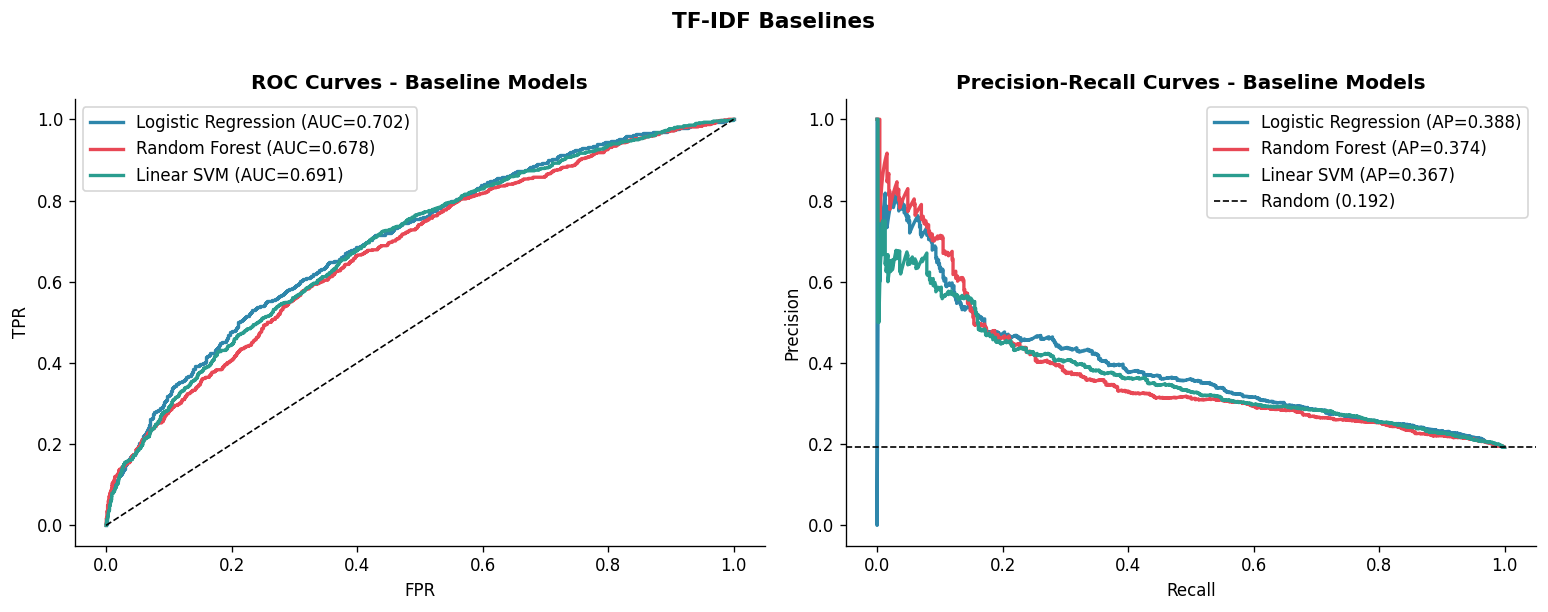

In [6]:
# Colour Mapping for Each Model
colors = {
    "Logistic Regression": "#2E86AB",
    "Random Forest": "#E84855",
    "Linear SVM": "#2A9D8F",
}

# ROC and Precision-Recall Curve Setup
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve Plotting
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])

    axes[0].plot(
        fpr,
        tpr,
        label=f'{name} (AUC={res["roc_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

# Random Baseline (ROC)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_title("ROC Curves - Baseline Models", fontweight="bold")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

# Precision-Recall Curve Plotting
baseline_pr = y_test.mean()

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])

    axes[1].plot(
        rec,
        prec,
        label=f'{name} (AP={res["pr_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

# Random Baseline (PR Curve)
axes[1].axhline(
    y=baseline_pr,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Random ({baseline_pr:.3f})",
)

axes[1].set_title(
    "Precision-Recall Curves - Baseline Models",
    fontweight="bold",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    "TF-IDF Baselines",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_01_roc_pr_curves.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Confusion Matrix Analysis

This section provides a detailed evaluation of baseline model performance using confusion matrices. Unlike aggregate metrics, confusion matrices offer a granular view of prediction outcomes by comparing true and predicted class labels.

Each matrix summarises four key quantities: true positives, true negatives, false positives, and false negatives. These components help identify specific strengths and weaknesses of each model, such as whether a model tends to over-predict the majority class or struggles to correctly identify readmitted patients.

For imbalanced classification tasks, confusion matrices are particularly useful for assessing recall and precision trade-offs in the minority class. In the context of readmission prediction, false negatives (missed readmissions) are often more critical than false positives, making this analysis essential for understanding real-world implications.

The matrices are visualised for all baseline models using a consistent colour scale to enable direct comparison of their classification behaviour.

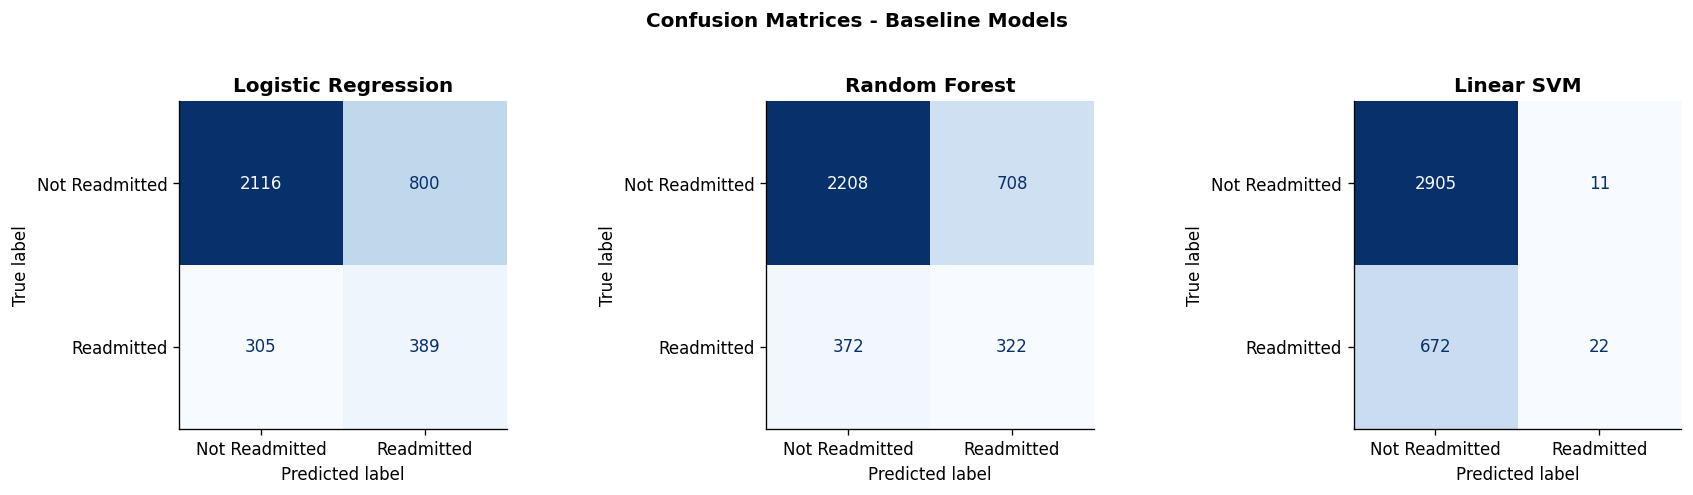

In [7]:
# Confusion Matrix Visualisation for Each Model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generate Confusion Matrix per Model
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Not Readmitted", "Readmitted"],
    ).plot(
        ax=ax,
        colorbar=False,
        cmap="Blues",
    )

    # Subplot Title (Model Name)
    ax.set_title(name, fontweight="bold")

# Figure Formatting and Save
plt.suptitle(
    "Confusion Matrices - Baseline Models",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_02_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Logistic Regression Feature Importance Analysis

This section examines the interpretability of the Logistic Regression model by analysing its learned feature coefficients. Unlike more complex models, Logistic Regression provides direct insight into feature importance through its weight parameters, making it highly suitable for understanding model behaviour.

Each coefficient represents the contribution of a feature to the prediction outcome. Positive coefficients indicate features associated with a higher likelihood of readmission, while negative coefficients correspond to features indicative of non-readmission.

The most influential features are identified by ranking coefficients in descending and ascending order. The top positive coefficients highlight strong predictors of readmission, whereas the top negative coefficients capture features associated with lower risk.

Visualising these features provides valuable interpretability, allowing us to connect model predictions to meaningful clinical patterns within the narratives. This is particularly important in healthcare applications, where transparency and explainability are critical for trust and adoption.

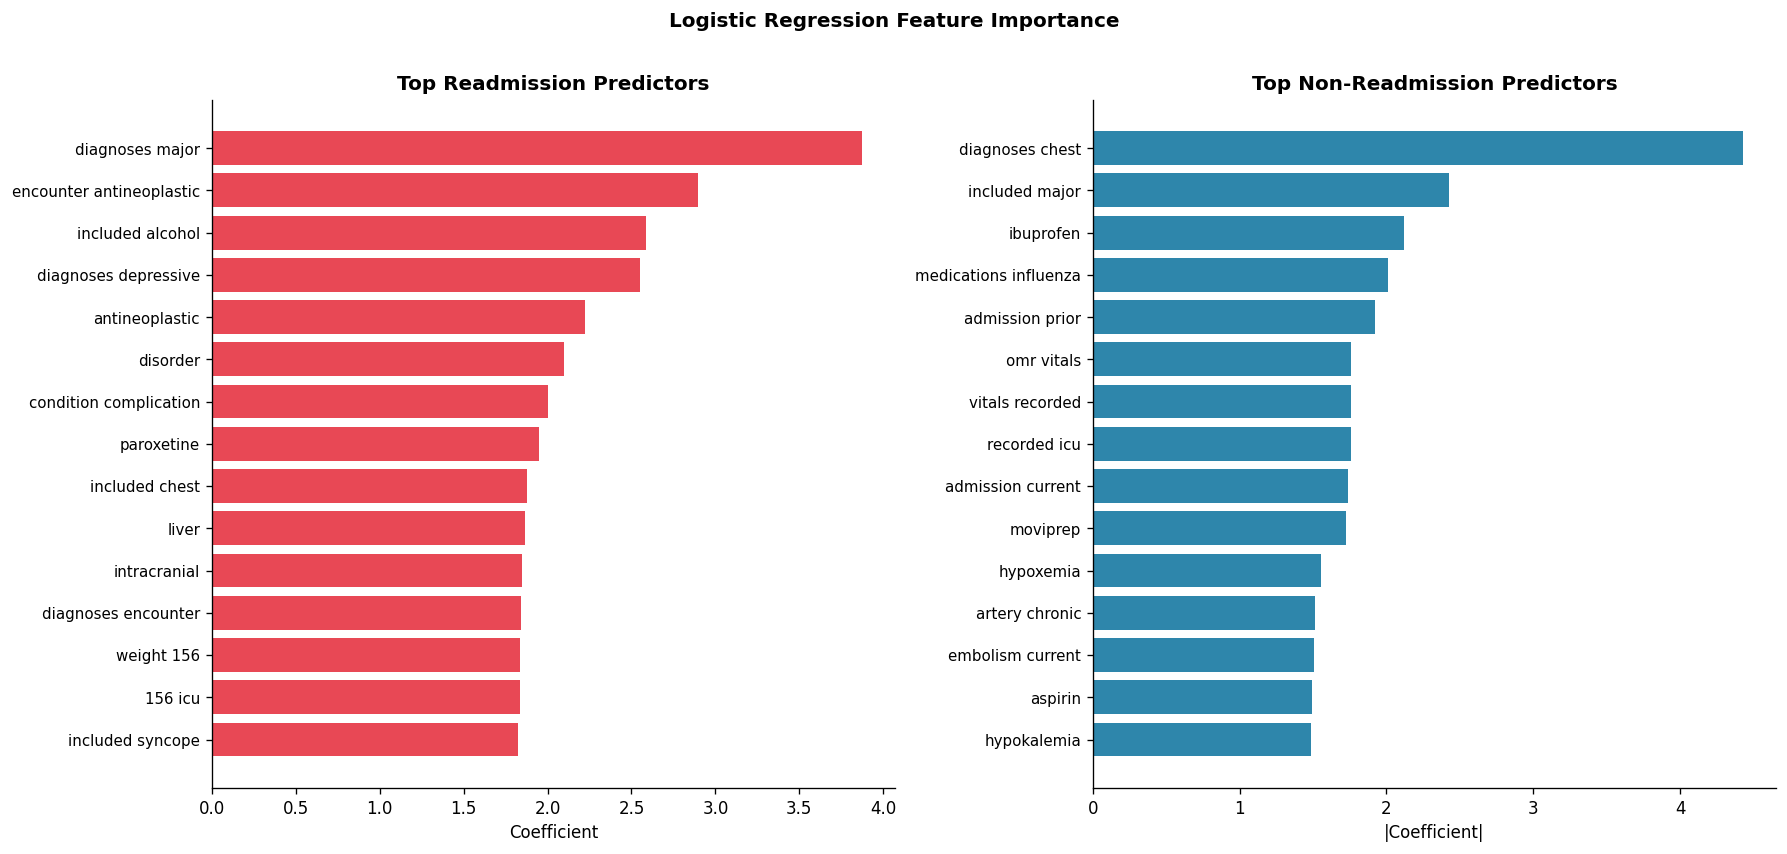

In [8]:
# Extract Trained Logistic Regression Model
lr_model = results["Logistic Regression"]["model"]

# Coefficients and Feature Names
coef       = lr_model.coef_[0]
feat_names = np.array(tfidf.get_feature_names_out())

# Top Positive and Negative Feature Indices
top_pos_idx = coef.argsort()[-20:][::-1]
top_neg_idx = coef.argsort()[:20]

# Feature Importance Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top Positive Coefficients (Readmission Predictors)
axes[0].barh(
    range(15),
    coef[top_pos_idx[:15]][::-1],
    color=PALETTE[1],
)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(
    feat_names[top_pos_idx[:15]][::-1],
    fontsize=9,
)
axes[0].set_title(
    "Top Readmission Predictors",
    fontweight="bold",
)
axes[0].set_xlabel("Coefficient")

# Top Negative Coefficients (Non-Readmission Predictors)
axes[1].barh(
    range(15),
    abs(coef[top_neg_idx[:15]][::-1]),
    color=PALETTE[0],
)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(
    feat_names[top_neg_idx[:15]][::-1],
    fontsize=9,
)
axes[1].set_title(
    "Top Non-Readmission Predictors",
    fontweight="bold",
)
axes[1].set_xlabel("|Coefficient|")

# Figure Formatting and Save
plt.suptitle(
    "Logistic Regression Feature Importance",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    f"{BASELINE_MODEL_PLT}/base_03_lr_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Model Comparison and Best Model Selection

This section consolidates the performance of all baseline models into a unified evaluation framework. Multiple metrics are considered, including accuracy, precision, recall, F1-score, ROC-AUC, and Precision–Recall AUC (PR-AUC), to provide a comprehensive comparison.

Given the imbalanced nature of the readmission prediction task, greater emphasis is placed on metrics such as ROC-AUC and PR-AUC, which offer threshold-independent evaluation and better reflect performance on the minority class.

A summary table is constructed to compare all models across these metrics, enabling clear identification of strengths and trade-offs. The best-performing model is selected based on ROC-AUC, as it captures the overall discriminative ability of the classifier across all thresholds.

Finally, the selected model, along with its associated artefacts (TF-IDF vectoriser, predictions, and probabilities), is saved for subsequent use in advanced modelling stages or deployment. This ensures reproducibility and facilitates seamless integration into later phases of the project.

In [9]:
# Compile Evaluation Summary Across Models
summary_rows = []

for name, res in results.items():
    r = res["report"]

    # Collect Metrics for Each Model
    summary_rows.append(
        {
            "Model" : name,
            "Type" : "Baseline",
            "Accuracy" : r["accuracy"],
            "Precision_Pos": r["1"]["precision"],
            "Recall_Pos" : r["1"]["recall"],
            "F1_Pos" : r["1"]["f1-score"],
            "F1_Weighted" : r["weighted avg"]["f1-score"],
            "ROC_AUC" : res["roc_auc"],
            "PR_AUC" : res["pr_auc"],
        }
    )

# Create Summary DataFrame
summary_df = pd.DataFrame(summary_rows)

# Save Results to CSV
summary_df.to_csv(BASELINE_RESULTS_CSV, index=False)

print("Baseline results saved.")
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

# Select Best Model (Based on ROC-AUC)
best_name = summary_df.loc[
    summary_df["ROC_AUC"].idxmax(),
    "Model"
]

best_res = results[best_name]

print(f"\nBest baseline: {best_name}")

# Save Best Model and Artifacts
with open(BEST_BASELINE_PKL, "wb") as f:
    pickle.dump(
        {
            "name" : best_name,
            "model" : best_res["model"],
            "tfidf" : tfidf,
            "y_test" : y_test,
            "y_pred" : best_res["y_pred"],
            "y_prob" : best_res["y_prob"],
        },
        f,
    )

Baseline results saved.
              Model     Type  Accuracy  Precision_Pos  Recall_Pos  F1_Pos  F1_Weighted  ROC_AUC  PR_AUC
Logistic Regression Baseline    0.6939         0.3272      0.5605  0.4132       0.7199   0.7021  0.3882
      Random Forest Baseline    0.7008         0.3126      0.4640  0.3735       0.7208   0.6776  0.3744
         Linear SVM Baseline    0.8108         0.6667      0.0317  0.0605       0.7344   0.6912  0.3666

Best baseline: Logistic Regression
